# IoT Intrusion Detection — Two-Stage Random Forest

This notebook builds a **two-stage pipeline** to address the BenignTraffic misclassification problem observed in the single-stage Random Forest.

**Architecture:**

```
Stage 1 — Binary RF:    BenignTraffic  vs.  Attack
Stage 2 — 33-class RF:  which attack?  (runs only on rows flagged as Attack by Stage 1)
```

**Why this helps:**
- Stage 1 is a much simpler problem — one decision boundary instead of 34. It can be fully optimized for recall on the benign/attack split without being pulled in 33 directions at once.
- Stage 2 never sees benign traffic, so it cannot misfire on it. Its entire capacity is spent separating attack families from each other.

**Primary metric: macro-F1** across all 34 classes on the final combined predictions.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit

from src.config import BASELINE_DIR, RANDOM_STATE
from src.data_pipeline import load_artifacts, load_split
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "two_stage_rf"

## 1. Load artifacts and splits

In [2]:
artifacts = load_artifacts()
X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  _ = load_split("test")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

X_train: (4086646, 47)   y_train: (4086646,)
X_val:   (875710, 47)   y_val:   (875710,)
X_test:  (875710, 47)   y_test:  (875710,)
Classes: 34


## 2. Subsample the training set

Same 15% stratified subsample (~614K rows) as the single-stage RF, so results are directly comparable.

In [3]:
SUBSAMPLE_FRAC = 0.30  # increase from 0.15 — RF benefits much more from data than LR does

sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSAMPLE_FRAC, random_state=RANDOM_STATE)
sub_idx, _ = next(sss.split(X_train, y_train))

X_train_sub = X_train.iloc[sub_idx].reset_index(drop=True)
y_train_sub = y_train.iloc[sub_idx].reset_index(drop=True)

print(f"Subsample: {X_train_sub.shape[0]:,} rows ({SUBSAMPLE_FRAC:.0%} of {X_train.shape[0]:,})")
print(f"Class counts (min/max): {y_train_sub.value_counts().min()} / {y_train_sub.value_counts().max()}")

Subsample: 1,225,993 rows (30% of 4,086,646)
Class counts (min/max): 263 / 60022


## 3. Stage 1 — Binary classifier (BenignTraffic vs. Attack)

Collapse all 33 attack classes into a single `"Attack"` label. Stage 1 only needs to answer one question: is this flow benign or not?

In [4]:
y_binary_train = y_train_sub.apply(lambda x: "BenignTraffic" if x == "BenignTraffic" else "Attack")

print("Stage 1 label distribution:")
print(y_binary_train.value_counts())

Stage 1 label distribution:
label
Attack           1165989
BenignTraffic      60004
Name: count, dtype: int64


In [5]:
stage1 = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

with timed(f"Stage 1 training (binary RF, {X_train_sub.shape[0]:,} rows)"):
    stage1.fit(X_train_sub, y_binary_train)

print(f"OOB accuracy: {stage1.oob_score_:.4f}")
print(f"Train accuracy: {stage1.score(X_train_sub, y_binary_train):.4f}")

Stage 1 training (binary RF, 1,225,993 rows): 146.3s
OOB accuracy: 0.9856
Train accuracy: 0.9899


### Stage 1 binary evaluation on validation

Check precision and recall specifically for `BenignTraffic` — high recall means fewer attacks slipping through as benign, high precision means fewer false alarms.

In [6]:
from sklearn.metrics import classification_report

y_binary_val = y_val.apply(lambda x: "BenignTraffic" if x == "BenignTraffic" else "Attack")
y_binary_pred_val = stage1.predict(X_val)

print("Stage 1 — validation binary report:")
print(classification_report(y_binary_val, y_binary_pred_val, digits=4))

Stage 1 — validation binary report:
               precision    recall  f1-score   support

       Attack     0.9978    0.9873    0.9925    832850
BenignTraffic     0.7948    0.9568    0.8683     42860

     accuracy                         0.9858    875710
    macro avg     0.8963    0.9720    0.9304    875710
 weighted avg     0.9878    0.9858    0.9864    875710



## 4. Stage 2 — 33-class attack classifier

Train only on attack rows from the subsampled training set. Stage 2 never sees benign traffic — its entire capacity goes toward separating attack families.

In [7]:
attack_mask_train = y_train_sub != "BenignTraffic"
X_train_attack = X_train_sub[attack_mask_train].reset_index(drop=True)
y_train_attack = y_train_sub[attack_mask_train].reset_index(drop=True)

print(f"Stage 2 training rows: {len(X_train_attack):,} (attack only)")
print(f"Attack classes: {y_train_attack.nunique()}")

Stage 2 training rows: 1,165,989 (attack only)
Attack classes: 33


In [8]:
stage2 = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

with timed(f"Stage 2 training (33-class RF, {len(X_train_attack):,} rows)"):
    stage2.fit(X_train_attack, y_train_attack)

print(f"OOB accuracy: {stage2.oob_score_:.4f}")
print(f"Train accuracy: {stage2.score(X_train_attack, y_train_attack):.4f}")

Stage 2 training (33-class RF, 1,165,989 rows): 241.6s
OOB accuracy: 0.9693
Train accuracy: 0.9889


## 5. Two-stage pipeline wrapper

A thin wrapper that chains the two models and exposes a single `.predict()` so it works with the existing `evaluate()` and `plot_confusion_matrix()` helpers.

In [9]:
STAGE1_THRESHOLD = 0.3  # lower = more aggressive attack flagging, fewer attacks lost to Stage 1

class TwoStageClassifier:
    def __init__(self, stage1, stage2, threshold=STAGE1_THRESHOLD):
        self.stage1 = stage1
        self.stage2 = stage2
        self.threshold = threshold

    def predict(self, X):
        proba = self.stage1.predict_proba(X)
        attack_idx = list(self.stage1.classes_).index("Attack")
        attack_mask = proba[:, attack_idx] >= self.threshold

        y_pred = np.empty(len(attack_mask), dtype=object)
        y_pred[:] = "BenignTraffic"

        if attack_mask.any():
            X_attack = X.iloc[attack_mask] if hasattr(X, "iloc") else X[attack_mask]
            y_pred[attack_mask] = self.stage2.predict(X_attack)

        return y_pred


pipeline = TwoStageClassifier(stage1, stage2)
print(f"Pipeline ready  (Stage 1 attack threshold = {STAGE1_THRESHOLD}).")

Pipeline ready  (Stage 1 attack threshold = 0.3).


## 6. Evaluate on validation

In [10]:
val_metrics = evaluate(pipeline, X_val, y_val, artifacts.label_encoder, split_name="val")

print(f"Validation results ({val_metrics.n_rows:,} rows):")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro-F1    = {val_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {val_metrics.weighted_f1:.4f}")

Validation results (875,710 rows):
  accuracy    = 0.9630
  macro-F1    = 0.8418   (primary)
  weighted-F1 = 0.9630


## 7. Per-class report

In [11]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Recon-PingSweep,0.3527,0.2684,0.3049,339.0000
BrowserHijacking,0.5175,0.4380,0.4744,879.0000
Backdoor_Malware,0.5022,0.4803,0.4910,483.0000
SqlInjection,0.5261,0.4612,0.4915,787.0000
Uploading_Attack,0.5581,0.5106,0.5333,188.0000
XSS,0.5438,0.5269,0.5352,577.0000
DictionaryBruteForce,0.5509,0.5799,0.5650,"1,959.0000"
CommandInjection,0.6091,0.6128,0.6109,811.0000
Recon-OSScan,0.7143,0.6588,0.6854,"14,739.0000"
Recon-PortScan,0.6924,0.7517,0.7209,"12,342.0000"


## 8. Confusion matrix on validation

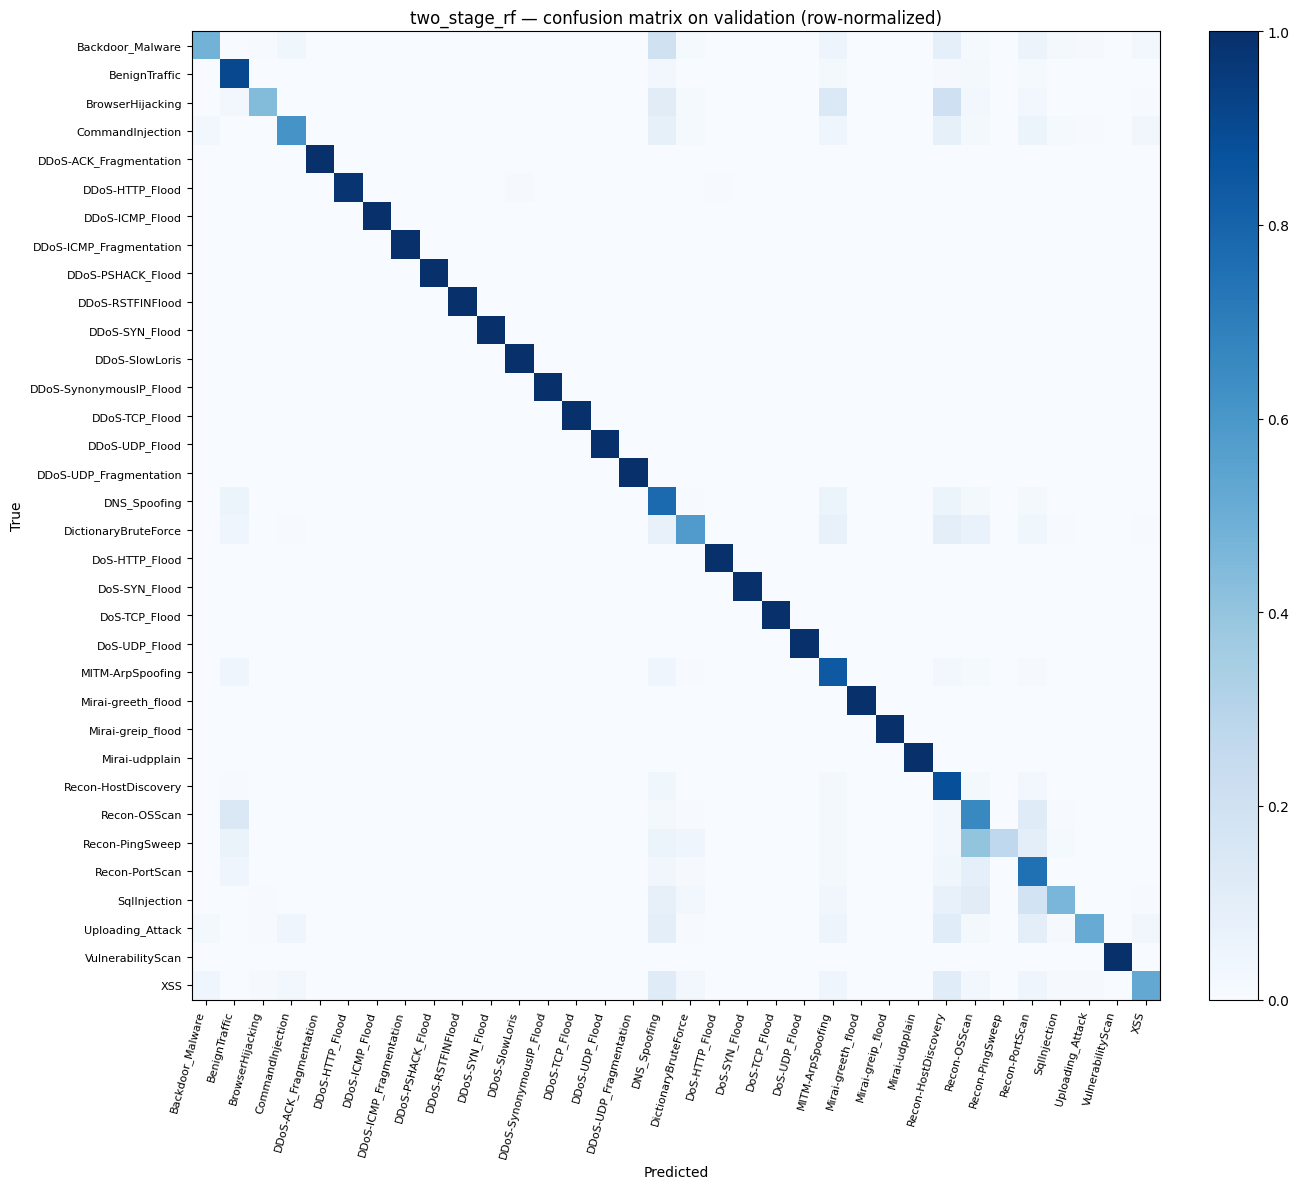

In [12]:
plot_confusion_matrix(
    pipeline, X_val, y_val, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on validation (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 9. Final test-set evaluation

In [13]:
test_metrics = evaluate(pipeline, X_test, y_test, artifacts.label_encoder, split_name="test")

print(f"Test results ({test_metrics.n_rows:,} rows):")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro-F1    = {test_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {test_metrics.weighted_f1:.4f}")

print(f"\nval → test macro-F1 delta: {test_metrics.macro_f1 - val_metrics.macro_f1:+.4f}")

Test results (875,710 rows):
  accuracy    = 0.9631
  macro-F1    = 0.8432   (primary)
  weighted-F1 = 0.9630

val → test macro-F1 delta: +0.0014


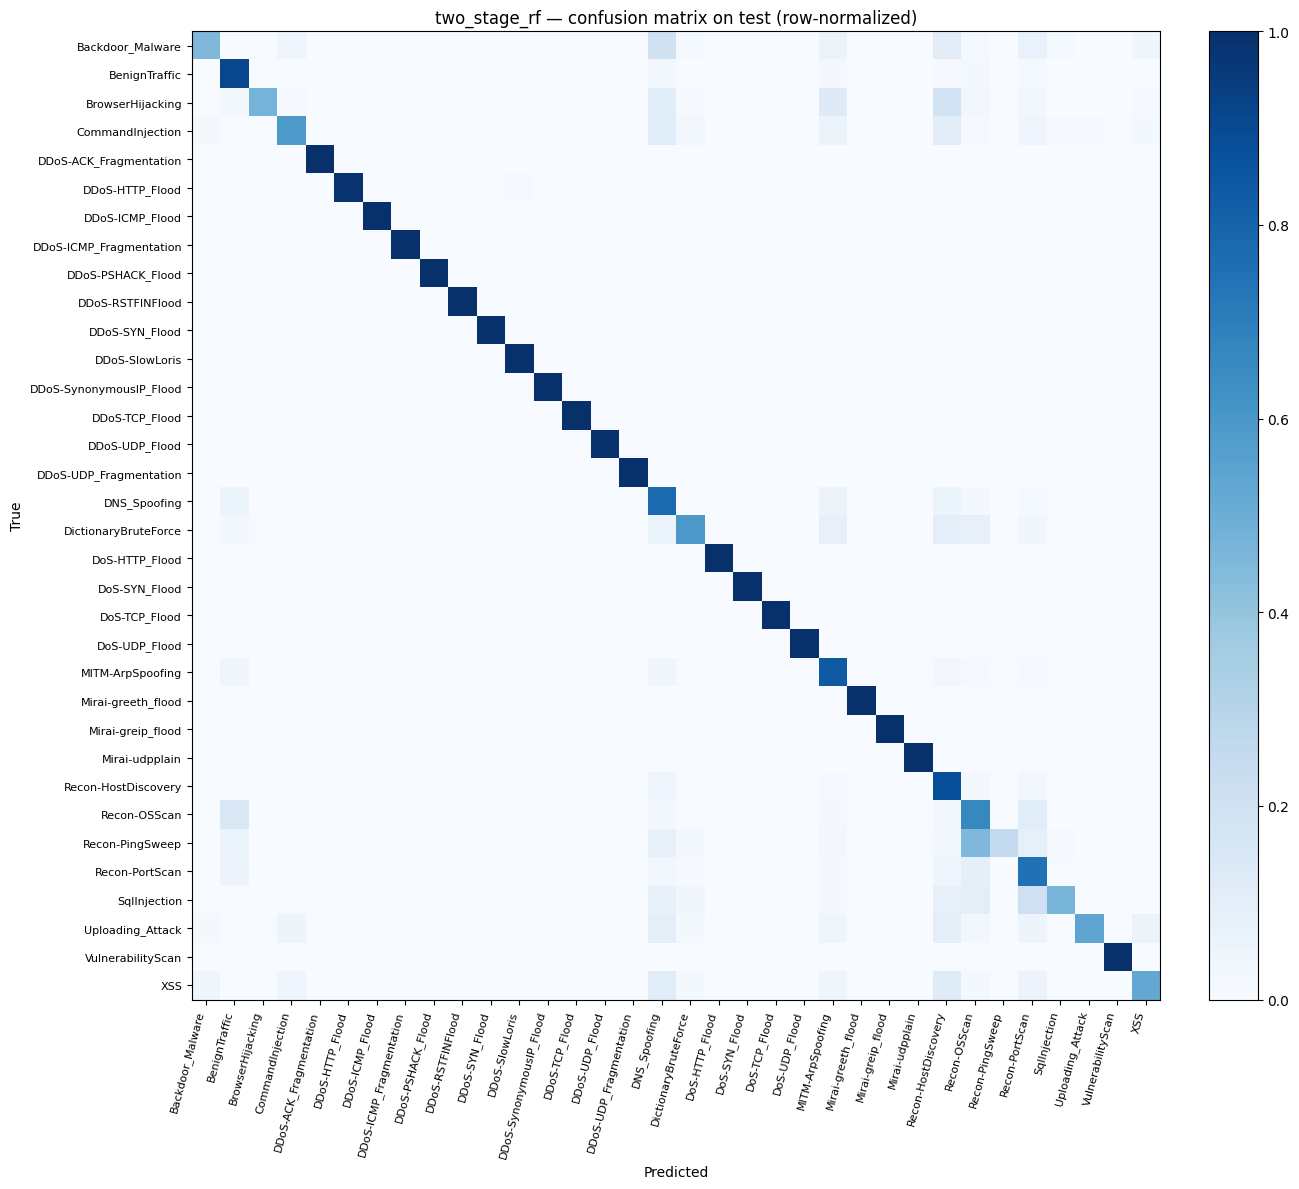

In [14]:
plot_confusion_matrix(
    pipeline, X_test, y_test, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on test (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 10. Persist the pipeline

In [15]:
output_dir = save_baseline(pipeline, [val_metrics, test_metrics], name=MODEL_NAME)

print(f"Saved to {output_dir}:")
for p in sorted(output_dir.glob(f"{MODEL_NAME}*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name}   ({size_kb:,.1f} KB)")

Saved to /Users/r/Desktop/iot-intrusion-detection/models/baseline:
  two_stage_rf.joblib   (2,326,436.3 KB)
  two_stage_rf_confusion_test.png   (164.5 KB)
  two_stage_rf_confusion_val.png   (165.5 KB)
  two_stage_rf_metrics.json   (12.4 KB)


## 11. Comparison against all previous models

In [16]:
import json

rows = []
for name in ["logistic_regression", "logistic_regression_v2", "random_forest", MODEL_NAME]:
    path = BASELINE_DIR / f"{name}_metrics.json"
    if not path.exists():
        continue
    raw = json.loads(path.read_text())
    splits = raw if isinstance(raw, list) else [raw]
    for m in splits:
        rows.append({
            "model": name,
            "split": m["split"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "weighted_f1": m["weighted_f1"],
        })

pd.DataFrame(rows).set_index(["model", "split"])

accuracy  macro_f1  weighted_f1
model                  split                                 
logistic_regression    val      0.7085    0.5090       0.7106
                       test     0.7085    0.5099       0.7106
logistic_regression_v2 val      0.7786    0.5708       0.7865
                       test     0.7802    0.5716       0.7879
random_forest          val      0.9602    0.8311       0.9602
                       test     0.9604    0.8327       0.9604
two_stage_rf           val      0.9630    0.8418       0.9630
                       test     0.9631    0.8432       0.9630